In [1]:
import pandas as pd 
from dotenv import load_dotenv
import os
import psycopg2

In [2]:
load_dotenv()
url = os.getenv('DATABASE_URL')

In [3]:
import sys
sys.path.append('..')
from src import backtester

In [4]:
conn = psycopg2.connect(url, sslmode="require")
cur = conn.cursor()

In [5]:
cur.execute("""
SELECT DISTINCT ticker FROM orderbooks
""")
rows = cur.fetchall()
tickers = [row[0] for row in rows]

In [6]:
from tqdm import tqdm
import time
returns = {}
for ticker in tqdm(tickers):
    while True:
        try:
            option_df, orders_df = backtester.load_datasets(url, ticker)
            break
        except Exception as e:
            print(e)
            time.sleep(20)
    returns[ticker] = backtester.run_backtest(option_df, orders_df, fee=0.00, plot=False)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 218/218 [20:19<00:00,  5.60s/it]


In [7]:
import numpy as np
import math

returns_arr = list(returns.values())
returns_arr = [x for x in returns_arr if x is not None and not math.isnan(x) and x != 0.0]
returns_arr = np.array(returns_arr)

otm_returns = np.array([x for key, x in returns.items() if int(key[2:5]) <= 320 and x is not None and not math.isnan(x) and x != 0.0])

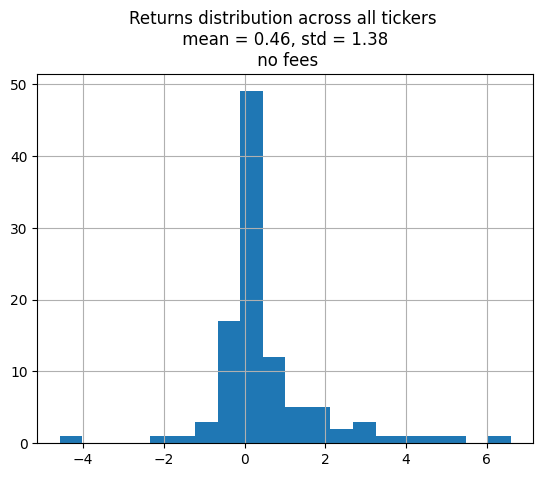

In [8]:
from matplotlib import pyplot as plt

plt.hist(returns_arr, bins=20)
plt.title(f"Returns distribution across all tickers \n mean = {returns_arr.mean():.2f}, std = {returns_arr.std():0.2f} \n no fees")
plt.grid()
plt.show()

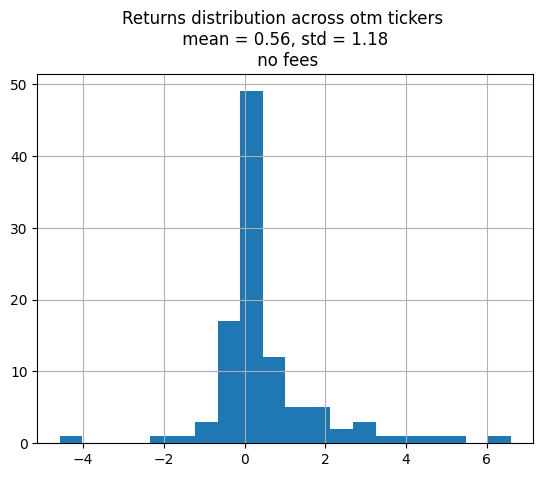

In [9]:
plt.hist(returns_arr, bins=20)
plt.title(f"Returns distribution across otm tickers \n mean = {otm_returns.mean():.2f}, std = {otm_returns.std():0.2f} \n no fees")
plt.grid()
plt.show()

In [10]:
from tqdm import tqdm
import time
fee_returns = {}
for ticker in tqdm(tickers):
    while True:
        try:
            option_df, orders_df = backtester.load_datasets(url, ticker)
            break
        except Exception as e:
            print(e)
            time.sleep(20)
    fee_returns[ticker] = backtester.run_backtest(option_df, orders_df, fee=0.01, plot=False)

 50%|██████████████████████████████████████████████████████████████████████                                                                      | 109/218 [09:46<10:31,  5.79s/it]

(psycopg2.OperationalError) could not translate host name "interchange.proxy.rlwy.net" to address: Name or service not known

(Background on this error at: https://sqlalche.me/e/20/e3q8)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 218/218 [20:50<00:00,  5.74s/it]


In [11]:
fee_returns_arr = list(fee_returns.values())
fee_returns_arr = [x for x in fee_returns_arr if x is not None and not math.isnan(x) and x != 0.0]
fee_returns_arr = np.array(fee_returns_arr)